# Grid ablation optimization benchmark

Compare `run_grid_ablation.py` (full pipeline per cell) vs `daniel_run_grid_ablation.py` (factorized) on the 10 `source.png` images from `grid_metrics_sdturbo_random10_20260626_104807`.

Sweep: 11×11 `t_start` by `t_end` grid, `t_delta=0.0` only.

In [21]:
import io
import json
import os
import subprocess
import sys
import time
from datetime import datetime
from pathlib import Path

import numpy as np
from PIL import Image

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "scripts":
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

CHORDEDIT_PYTHON = Path("/data/home/mirick/miniconda3/envs/chordedit/bin/python")
PYTHON = Path(os.environ.get("BENCHMARK_PYTHON", CHORDEDIT_PYTHON if CHORDEDIT_PYTHON.exists() else sys.executable))

GPU_STR = "2"
GPU_ID = os.environ.get("BENCHMARK_GPU", GPU_STR)
MODEL_ROOT = "/shared/ssd_30T/mirick/models/sd-turbo"
GRID_ROOT = Path("/shared/ssd_30T/mirick/grid_metrics_sdturbo_random10_20260626_104807")
PIE_MAPPING = Path("/shared/ssd_30T/mirick/datasets/PIE-Bench_v1/mapping_file.json")

BENCH_ROOT = REPO_ROOT / "outputs" / "benchmark_random10"
DATA_ROOT = BENCH_ROOT / "data"
JPEG_QUALITY = 75  # matches daniel_run_grid_ablation.py


def latest_benchmark_dirs(bench_root: Path) -> tuple[Path, Path]:
    """Return the newest matching run_grid_ablation_* / daniel_run_grid_ablation_* pair."""
    ref_dirs = sorted(bench_root.glob("run_grid_ablation_*"))
    if not ref_dirs:
        raise FileNotFoundError(f"No run_grid_ablation_* directories under {bench_root}")

    ref_out = ref_dirs[-1]
    suffix = ref_out.name.removeprefix("run_grid_ablation_")
    dan_out = bench_root / f"daniel_run_grid_ablation_{suffix}"
    if not dan_out.is_dir():
        dan_dirs = sorted(bench_root.glob("daniel_run_grid_ablation_*"))
        if not dan_dirs:
            raise FileNotFoundError(f"No daniel_run_grid_ablation_* directories under {bench_root}")
        dan_out = dan_dirs[-1]
    return ref_out, dan_out


def new_benchmark_dirs(bench_root: Path) -> tuple[Path, Path]:
    """Create fresh timestamped output paths for a new ablation run."""
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    return (
        bench_root / f"run_grid_ablation_{ts}",
        bench_root / f"daniel_run_grid_ablation_{ts}",
    )


# Default to the most recent completed benchmark pair (safe for comparison cells).
REF_OUT, DAN_OUT = latest_benchmark_dirs(BENCH_ROOT)

print(f"repo: {REPO_ROOT}")
print(f"python: {PYTHON}")
print(f"GPU: {GPU_ID}")
print(f"REF_OUT: {REF_OUT}")
print(f"DAN_OUT: {DAN_OUT}")

repo: /data/home/mirick/ChordEdit/daniel-grid-optimizations
python: /data/home/mirick/miniconda3/envs/chordedit/bin/python
GPU: 2
REF_OUT: /data/home/mirick/ChordEdit/daniel-grid-optimizations/outputs/benchmark_random10/run_grid_ablation_20260706_203945
DAN_OUT: /data/home/mirick/ChordEdit/daniel-grid-optimizations/outputs/benchmark_random10/daniel_run_grid_ablation_20260706_203945


In [14]:
def prepare_benchmark_data() -> int:
    mapping = json.loads(PIE_MAPPING.read_text(encoding="utf-8"))
    sources = sorted(GRID_ROOT.glob("*/source.png"))
    if not sources:
        raise FileNotFoundError(f"No source.png under {GRID_ROOT}")

    DATA_ROOT.mkdir(parents=True, exist_ok=True)
    for src in sources:
        sample_dir = DATA_ROOT / src.parent.name
        sample_dir.mkdir(exist_ok=True)
        img_link = sample_dir / "i.jpg"
        if img_link.exists() or img_link.is_symlink():
            img_link.unlink()
        img_link.symlink_to(src.resolve())
        sample_id = src.parent.name.split("_")[-1]
        meta = mapping[sample_id]
        record = {
            "edit_id": "e1",
            "original_prompt": meta["original_prompt"],
            "edited_prompt": meta["editing_prompt"],
            "edit_prompt": meta["editing_instruction"],
            "task_type": "object",
        }
        (sample_dir / "meta.jsonl").write_text(json.dumps(record) + "\n", encoding="utf-8")
    return len(sources)

n_samples = prepare_benchmark_data()
print(f"Prepared {n_samples} samples under {DATA_ROOT}")

Prepared 10 samples under /data/home/mirick/ChordEdit/daniel-grid-optimizations/outputs/benchmark_random10/data


In [15]:
def run_ablation(script_name: str, output_root: Path) -> float:
    cmd = [
        str(PYTHON),
        str(REPO_ROOT / "scripts" / script_name),
        "--model-root", MODEL_ROOT,
        "--model-type", "sd",
        "--data-root", str(DATA_ROOT),
        "--output-root", str(output_root),
        "--max-records", str(int(os.environ.get("BENCHMARK_MAX_RECORDS", n_samples))),
        "--overwrite",
        "--device", "cuda:0",
    ]
    env = os.environ.copy()
    env["CUDA_VISIBLE_DEVICES"] = GPU_ID
    print(" ".join(cmd))
    t0 = time.perf_counter()
    proc = subprocess.run(cmd, cwd=REPO_ROOT, env=env, check=True)
    elapsed = time.perf_counter() - t0
    print(f"{script_name} finished in {elapsed:.1f}s (exit {proc.returncode})")
    return elapsed

In [4]:
REF_OUT, DAN_OUT = new_benchmark_dirs(BENCH_ROOT)
print(f"New benchmark run -> REF_OUT={REF_OUT.name}, DAN_OUT={DAN_OUT.name}")
ref_seconds = run_ablation("run_grid_ablation.py", REF_OUT)

/data/home/mirick/miniconda3/envs/chordedit/bin/python /data/home/mirick/ChordEdit/daniel-grid-optimizations/scripts/run_grid_ablation.py --model-root /shared/ssd_30T/mirick/models/sd-turbo --model-type sd --data-root /data/home/mirick/ChordEdit/daniel-grid-optimizations/outputs/benchmark_random10/data --output-root /data/home/mirick/ChordEdit/daniel-grid-optimizations/outputs/benchmark_random10/run_grid_ablation_20260706_203945 --max-records 10 --overwrite --device cuda:0


2026-07-06 20:39:54,727 | INFO | grid_ablation | Loaded 10 record(s) from /data/home/mirick/ChordEdit/daniel-grid-optimizations/outputs/benchmark_random10/data
2026-07-06 20:39:54,727 | INFO | grid_ablation | Base edit config copied from app.py: {'noise_samples': 1, 'n_steps': 1, 't_start': 0.9, 't_end': 0.3, 't_delta': 0.0, 'step_scale': 1.0, 'cleanup': True}
2026-07-06 20:39:54,727 | INFO | grid_ablation | Grid values: [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
2026-07-06 20:39:54,728 | INFO | grid_ablation | t_delta conditions: [0.0]
2026-07-06 20:39:54,728 | INFO | grid_ablation | Output root: /data/home/mirick/ChordEdit/daniel-grid-optimizations/outputs/benchmark_random10/run_grid_ablation_20260706_203945
Loading weights: 100%|██████████| 372/372 [00:00<00:00, 4434.30it/s]
2026-07-06 20:39:59,357 | INFO | grid_ablation | Processing 1/10: 0_random_140_000000000000_e1


t_start:        0.0 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        0.1 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        0.2 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        0.3 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        0.4 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        0.5 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        0.6 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        0.7 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        0.8 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        0.9 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        1.0 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        0.0 t_end:        0.1 t_delta:        0.0 n_steps:          1
t_start:        0.1 t_end:        0.1 t_delta:        0.0 n_step

2026-07-06 20:41:22,411 | INFO | grid_ablation | Processing 2/10: 0_random_140_000000000001_e1


t_start:        0.0 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        0.1 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        0.2 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        0.3 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        0.4 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        0.5 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        0.6 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        0.7 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        0.8 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        0.9 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        1.0 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        0.0 t_end:        0.1 t_delta:        0.0 n_steps:          1
t_start:        0.1 t_end:        0.1 t_delta:        0.0 n_step

...

t_start:        0.0 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        0.1 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        0.2 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        0.3 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        0.4 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        0.5 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        0.6 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        0.7 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        0.8 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        0.9 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        1.0 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        0.0 t_end:        0.1 t_delta:        0.0 n_steps:          1
t_start:        0.1 t_end:        0.1 t_delta:        0.0 n_step

2026-07-06 20:52:43,402 | INFO | grid_ablation | Processing 10/10: 0_random_140_000000000009_e1


t_start:        0.0 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        0.1 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        0.2 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        0.3 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        0.4 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        0.5 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        0.6 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        0.7 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        0.8 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        0.9 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        1.0 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        0.0 t_end:        0.1 t_delta:        0.0 n_steps:          1
t_start:        0.1 t_end:        0.1 t_delta:        0.0 n_step

2026-07-06 20:53:59,182 | INFO | grid_ablation | Finished grid ablations. Results saved in /data/home/mirick/ChordEdit/daniel-grid-optimizations/outputs/benchmark_random10/run_grid_ablation_20260706_203945


run_grid_ablation.py finished in 854.3s (exit 0)


In [5]:
dan_seconds = run_ablation("daniel_run_grid_ablation.py", DAN_OUT)

/data/home/mirick/miniconda3/envs/chordedit/bin/python /data/home/mirick/ChordEdit/daniel-grid-optimizations/scripts/daniel_run_grid_ablation.py --model-root /shared/ssd_30T/mirick/models/sd-turbo --model-type sd --data-root /data/home/mirick/ChordEdit/daniel-grid-optimizations/outputs/benchmark_random10/data --output-root /data/home/mirick/ChordEdit/daniel-grid-optimizations/outputs/benchmark_random10/daniel_run_grid_ablation_20260706_203945 --max-records 10 --overwrite --device cuda:0


2026-07-06 20:54:08,136 | INFO | daniel_grid_ablation | Loaded 10 record(s) from /data/home/mirick/ChordEdit/daniel-grid-optimizations/outputs/benchmark_random10/data
2026-07-06 20:54:08,136 | INFO | daniel_grid_ablation | Base edit config: {'noise_samples': 1, 'n_steps': 1, 't_start': 0.9, 't_end': 0.3, 't_delta': 0.0, 'step_scale': 1.0, 'cleanup': True}
2026-07-06 20:54:08,137 | INFO | daniel_grid_ablation | Grid values: [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0] (11x11 = 121 cells/image/t_delta)
2026-07-06 20:54:08,137 | INFO | daniel_grid_ablation | t_delta conditions: [0.0]
2026-07-06 20:54:08,137 | INFO | daniel_grid_ablation | Chord edit mode: default
2026-07-06 20:54:08,137 | INFO | daniel_grid_ablation | Per image/t_delta: 1 encode, 1 prompt encode, 1 noise setup, 11 transports, 121 cleanups, 121 decodes (run_grid_ablation.py would run 121 full pipelines)
2026-07-06 20:54:08,137 | INFO | daniel_grid_ablation | Output root: /data/home/mirick/ChordEdit/daniel-grid-o

Using t_delta=0 fast path ...
Using t_delta=0 fast path ...
Using t_delta=0 fast path ...
Using t_delta=0 fast path ...
Using t_delta=0 fast path ...
Using t_delta=0 fast path ...
Using t_delta=0 fast path ...
Using t_delta=0 fast path ...
Using t_delta=0 fast path ...
Using t_delta=0 fast path ...
Using t_delta=0 fast path ...


2026-07-06 20:54:29,724 | INFO | daniel_grid_ablation | Processing 2/10: 0_random_140_000000000001_e1


Using t_delta=0 fast path ...
Using t_delta=0 fast path ...
Using t_delta=0 fast path ...
Using t_delta=0 fast path ...
Using t_delta=0 fast path ...
Using t_delta=0 fast path ...
Using t_delta=0 fast path ...
Using t_delta=0 fast path ...
Using t_delta=0 fast path ...
Using t_delta=0 fast path ...
Using t_delta=0 fast path ...


...

Using t_delta=0 fast path ...
Using t_delta=0 fast path ...
Using t_delta=0 fast path ...
Using t_delta=0 fast path ...
Using t_delta=0 fast path ...
Using t_delta=0 fast path ...
Using t_delta=0 fast path ...
Using t_delta=0 fast path ...
Using t_delta=0 fast path ...
Using t_delta=0 fast path ...
Using t_delta=0 fast path ...


2026-07-06 20:56:59,236 | INFO | daniel_grid_ablation | Processing 10/10: 0_random_140_000000000009_e1


Using t_delta=0 fast path ...
Using t_delta=0 fast path ...
Using t_delta=0 fast path ...
Using t_delta=0 fast path ...
Using t_delta=0 fast path ...
Using t_delta=0 fast path ...
Using t_delta=0 fast path ...
Using t_delta=0 fast path ...
Using t_delta=0 fast path ...
Using t_delta=0 fast path ...
Using t_delta=0 fast path ...


2026-07-06 20:57:17,866 | INFO | daniel_grid_ablation | Finished grid ablations. Results saved in /data/home/mirick/ChordEdit/daniel-grid-optimizations/outputs/benchmark_random10/daniel_run_grid_ablation_20260706_203945


daniel_run_grid_ablation.py finished in 198.9s (exit 0)


In [22]:
def png_as_jpeg_array(png_path: Path) -> np.ndarray:
    img = Image.open(png_path).convert("RGB")
    buf = io.BytesIO()
    img.save(buf, format="JPEG", quality=JPEG_QUALITY)
    buf.seek(0)
    return np.asarray(Image.open(buf).convert("RGB"))


def psnr(ref: np.ndarray, pred: np.ndarray, data_range: float = 255.0) -> float:
    """Whole-image PSNR in dB (higher = more similar)."""
    mse = np.mean((ref.astype(np.float64) - pred.astype(np.float64)) ** 2)
    if mse == 0.0:
        return float("inf")
    return float(10.0 * np.log10((data_range**2) / mse))


def compare_outputs(ref_root: Path, dan_root: Path) -> dict:
    ref_cells = {p.stem: p for p in ref_root.rglob("t_delta_0/cells/*.png")}
    dan_cells = {p.stem: p for p in dan_root.rglob("t_delta_0/cells/*.jpg")}
    common = sorted(set(ref_cells) & set(dan_cells))
    only_ref = sorted(set(ref_cells) - set(dan_cells))
    only_dan = sorted(set(dan_cells) - set(ref_cells))

    scores: list[float] = []
    worst = (float("inf"), None)
    for stem in common:
        ref_jpg = png_as_jpeg_array(ref_cells[stem])
        dan_arr = np.asarray(Image.open(dan_cells[stem]).convert("RGB"))
        score = psnr(ref_jpg, dan_arr)
        scores.append(score)
        if score < worst[0]:
            worst = (score, stem)

    finite = [s for s in scores if np.isfinite(s)]
    return {
        "ref_root": str(ref_root),
        "dan_root": str(dan_root),
        "ref_cells": len(ref_cells),
        "dan_cells": len(dan_cells),
        "common": len(common),
        "only_ref": len(only_ref),
        "only_dan": len(only_dan),
        "mean_psnr_db": round(float(np.mean(finite)), 3) if finite else None,
        "min_psnr_db": round(float(np.min(finite)), 3) if finite else None,
        "max_psnr_db": round(float(np.max(finite)), 3) if finite else None,
        "worst_cell_psnr_db": worst,
    }


if not REF_OUT.is_dir() or not DAN_OUT.is_dir():
    REF_OUT, DAN_OUT = latest_benchmark_dirs(BENCH_ROOT)
    print(f"Using latest benchmark pair: {REF_OUT.name} / {DAN_OUT.name}")

comparison = compare_outputs(REF_OUT, DAN_OUT)
comparison

{'ref_root': '/data/home/mirick/ChordEdit/daniel-grid-optimizations/outputs/benchmark_random10/run_grid_ablation_20260706_203945',
 'dan_root': '/data/home/mirick/ChordEdit/daniel-grid-optimizations/outputs/benchmark_random10/daniel_run_grid_ablation_20260706_203945',
 'ref_cells': 121,
 'dan_cells': 121,
 'common': 121,
 'only_ref': 0,
 'only_dan': 0,
 'mean_psnr_db': 52.553,
 'min_psnr_db': 48.755,
 'max_psnr_db': 58.392,
 'worst_cell_psnr_db': (48.755332078116524, 't_start_0p8__t_end_1p0')}

In [23]:
cells_per_image = 11 * 11
total_cells = cells_per_image * n_samples
speedup = ref_seconds / dan_seconds if dan_seconds else float("inf")

summary = {
    "samples": n_samples,
    "cells_per_image": cells_per_image,
    "total_cells": total_cells,
    "t_delta": 0.0,
    "run_grid_ablation_s": round(ref_seconds, 1),
    "daniel_grid_ablation_s": round(dan_seconds, 1),
    "speedup": round(speedup, 2),
    "sec_per_cell_ref": round(ref_seconds / total_cells, 3),
    "sec_per_cell_daniel": round(dan_seconds / total_cells, 3),
    **comparison,
}
summary

{'samples': 10,
 'cells_per_image': 121,
 'total_cells': 1210,
 't_delta': 0.0,
 'run_grid_ablation_s': 854.3,
 'daniel_grid_ablation_s': 198.9,
 'speedup': 4.29,
 'sec_per_cell_ref': 0.706,
 'sec_per_cell_daniel': 0.164,
 'ref_root': '/data/home/mirick/ChordEdit/daniel-grid-optimizations/outputs/benchmark_random10/run_grid_ablation_20260706_203945',
 'dan_root': '/data/home/mirick/ChordEdit/daniel-grid-optimizations/outputs/benchmark_random10/daniel_run_grid_ablation_20260706_203945',
 'ref_cells': 121,
 'dan_cells': 121,
 'common': 121,
 'only_ref': 0,
 'only_dan': 0,
 'mean_psnr_db': 52.553,
 'min_psnr_db': 48.755,
 'max_psnr_db': 58.392,
 'worst_cell_psnr_db': (48.755332078116524, 't_start_0p8__t_end_1p0')}

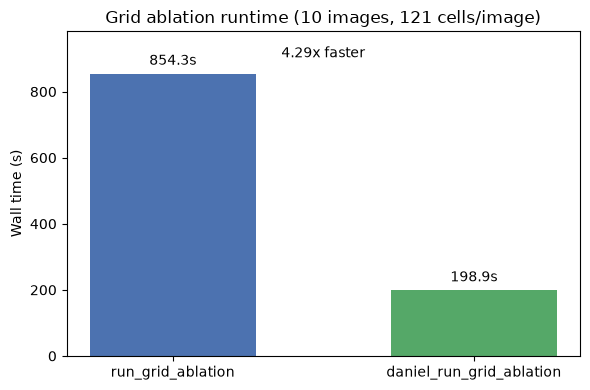

Saved /data/home/mirick/ChordEdit/daniel-grid-optimizations/outputs/benchmark_random10/runtime_comparison.png


In [24]:
import matplotlib.pyplot as plt

labels = ["run_grid_ablation", "daniel_run_grid_ablation"]
times_s = [ref_seconds, dan_seconds]
colors = ["#4C72B0", "#55A868"]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, times_s, color=colors, width=0.55)
ax.set_ylabel("Wall time (s)")
ax.set_title(f"Grid ablation runtime ({n_samples} images, {cells_per_image} cells/image)")
ax.bar_label(bars, labels=[f"{t:.1f}s" for t in times_s], padding=4)
ax.text(
    0.5, 0.92, f"{speedup:.2f}x faster",
    transform=ax.transAxes, ha="center", fontsize=10,
)
ax.set_ylim(0, max(times_s) * 1.15)
fig.tight_layout()

plot_path = BENCH_ROOT / "runtime_comparison.png"
fig.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {plot_path}")

In [29]:
def compare_outputs_per_sample(ref_root: Path, dan_root: Path) -> list[dict]:
    rows = []
    for sample_dir in sorted(p for p in ref_root.iterdir() if p.is_dir()):
        dan_dir = dan_root / sample_dir.name
        cells_dir = sample_dir / "t_delta_0/cells"
        if not cells_dir.is_dir() or not dan_dir.is_dir():
            continue

        scores: list[float] = []
        missing = 0
        for ref_path in sorted(cells_dir.glob("*.png")):
            dan_path = dan_dir / "t_delta_0/cells" / f"{ref_path.stem}.jpg"
            if not dan_path.exists():
                missing += 1
                continue
            ref_jpg = png_as_jpeg_array(ref_path)
            dan_arr = np.asarray(Image.open(dan_path).convert("RGB"))
            scores.append(psnr(ref_jpg, dan_arr))

        finite = [s for s in scores if np.isfinite(s)]
        sample_id = sample_dir.name.split("_")[-2]
        rows.append({
            "sample": sample_dir.name,
            "sample_id": sample_id,
            "cells": len(scores) + missing,
            "missing_cells": missing,
            "psnr_scores": finite,
            "mean_psnr_db": round(float(np.mean(finite)), 3) if finite else None,
            "min_psnr_db": round(float(np.min(finite)), 3) if finite else None,
            "max_psnr_db": round(float(np.max(finite)), 3) if finite else None,
        })
    return rows


if not REF_OUT.is_dir() or not DAN_OUT.is_dir():
    REF_OUT, DAN_OUT = latest_benchmark_dirs(BENCH_ROOT)

per_sample = compare_outputs_per_sample(REF_OUT, DAN_OUT)
per_sample

[{'sample': '0_random_140_000000000000_e1',
  'sample_id': '000000000000',
  'cells': 121,
  'missing_cells': 0,
  'psnr_scores': [52.265098696145145,
   51.76067402183429,
   51.2796819244134,
   51.69345484111549,
   50.73500138353359,
   50.51277410252968,
   49.89571897856196,
   49.21569507652328,
   47.440379373882784,
   45.896678525515036,
   43.84538126913621,
   51.80067750322242,
   51.36575365570174,
   52.254681299562534,
   51.09933528076649,
   50.63281932260415,
   49.59384815910568,
   49.40717209024533,
   49.18090509617282,
   47.22281980655193,
   46.07391488468974,
   44.45887903421023,
   51.105191574691375,
   50.62036948497127,
   50.863534170795084,
   50.46261365418495,
   50.57992172154059,
   50.34406827226195,
   49.45977473470559,
   48.991091099153564,
   47.48732889627773,
   45.5569597920498,
   44.194710654601906,
   50.42138391202162,
   50.84899116563037,
   50.85803603102582,
   50.10186917313171,
   50.088249350071706,
   50.12144038128214,
   49.5

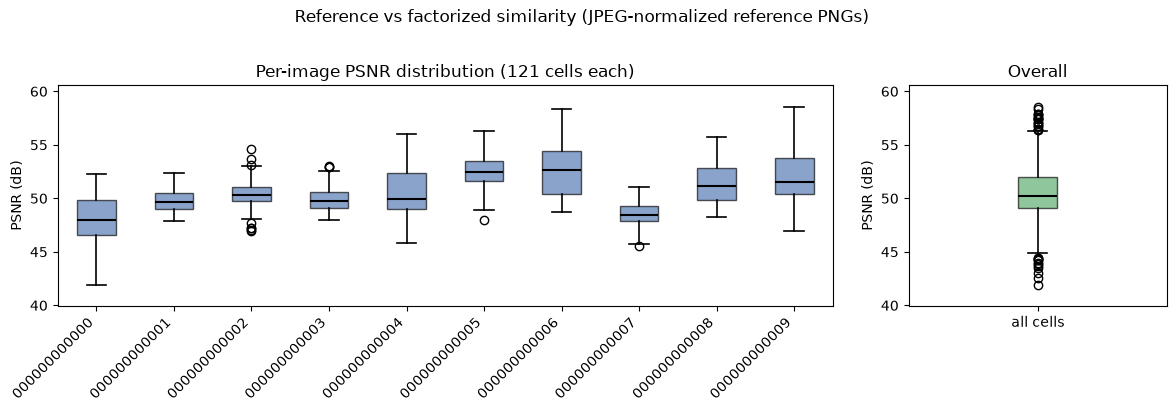

Saved /data/home/mirick/ChordEdit/daniel-grid-optimizations/outputs/benchmark_random10/per_image_similarity.png


In [30]:
sample_labels = [row["sample_id"] for row in per_sample]
psnr_by_sample = [row["psnr_scores"] for row in per_sample]
all_psnr = [score for scores in psnr_by_sample for score in scores]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={"width_ratios": [3, 1]})

bp = axes[0].boxplot(
    psnr_by_sample,
    tick_labels=sample_labels,
    patch_artist=True,
    showfliers=True,
    whis=1.5,
    medianprops={"color": "black", "linewidth": 1.5},
    whiskerprops={"linewidth": 1.2},
    capprops={"linewidth": 1.2},
)
for patch in bp["boxes"]:
    patch.set_facecolor("#4C72B0")
    patch.set_alpha(0.65)
axes[0].set_xticklabels(sample_labels, rotation=45, ha="right")
axes[0].set_ylabel("PSNR (dB)")
axes[0].set_title("Per-image PSNR distribution (121 cells each)")

bp_all = axes[1].boxplot(
    [all_psnr],
    tick_labels=["all cells"],
    patch_artist=True,
    showfliers=True,
    whis=1.5,
    medianprops={"color": "black", "linewidth": 1.5},
    whiskerprops={"linewidth": 1.2},
    capprops={"linewidth": 1.2},
)
bp_all["boxes"][0].set_facecolor("#55A868")
bp_all["boxes"][0].set_alpha(0.65)
axes[1].set_ylabel("PSNR (dB)")
axes[1].set_title("Overall")
if all_psnr:
    ymin = min(all_psnr)
    ymax = max(all_psnr)
    axes[0].set_ylim(max(0, ymin - 2), ymax + 2)
    axes[1].set_ylim(max(0, ymin - 2), ymax + 2)

fig.suptitle("Reference vs factorized similarity (JPEG-normalized reference PNGs)", y=1.02)
fig.tight_layout()

similarity_plot_path = BENCH_ROOT / "per_image_similarity.png"
fig.savefig(similarity_plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {similarity_plot_path}")